In [85]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pre_processing import pre_process, json_decode


sns.set_palette("hsv_r")

# This affects things like the size of the labels, lines, and other elements of the plot, but not the overall style. 
# The base context is “notebook”, and the other contexts are “paper”, “talk”, and “poster”, which are version of 
# the notebook parameters scaled by .8, 1.3, and 1.6, respectively.
sns.set_context("talk")

%config Inline.figure_format = 'retina'
%matplotlib inline

# new 

## Read in Data 

In [86]:
# File paths for each experimental condition (can contain multiple subjects/files) 
file_paths_baseline = [
    "../data/csv_files/01_baseline_withoutFB.csv",
    "../data/csv_files/02_baseline_withoutFB.csv",
    "../data/csv_files/03_baseline_withoutFB.csv",
    "../data/csv_files/04_baseline_withoutFB.csv", 
    "../data/csv_files/05_baseline_withoutFB.csv"
]

file_paths_repulse = [
    "../data/csv_files/01_repulse_withoutFB.csv",
    "../data/csv_files/02_repulse_withoutFB.csv",
    "../data/csv_files/03_repulse_withoutFB.csv",
    "../data/csv_files/04_repulse_withoutFB.csv", 
    "../data/csv_files/05_repulse_withoutFB.csv"
]

file_paths_udl = [
    "../data/csv_files/01_udl_withoutFB.csv",
    "../data/csv_files/02_udl_withoutFB.csv",
    "../data/csv_files/03_udl_withoutFB.csv",
    "../data/csv_files/04_udl_withoutFB.csv", 
    "../data/csv_files/05_udl_withoutFB.csv"
]
# Subject identifiers corresponding to the datasets
subject_list = ["abby", "yannie", "eric", "paul", "jason"]

# Load CSV files & label condition
df_baseline_raw = pre_process(file_paths_baseline, subject_list)
df_baseline_raw['phase'] = 'baseline'

df_repulse_raw = pre_process(file_paths_repulse, subject_list)
df_repulse_raw['phase'] = 'repulse'

df_udl_raw = pre_process(file_paths_udl, subject_list)
df_udl_raw['phase'] = 'udl'

# Combine all conditions into a single dataset
df = pd.concat([df_baseline_raw, df_repulse_raw, df_udl_raw]).reset_index(drop=True)

# Reset the trial number column that resets for each subject
df["TN"] = df.groupby("SN").cumcount()

# CHECK 
# print(df['phase'].value_counts())
# print(df.head())


## Define Functions 

In [87]:
# function to unpack repeated target value from series
# WE HAVENT USE THIS ONE YET.. copied from Jeremy's analysis script
def find_rep(group):
    vals = group['Repeated_Target'].iloc[0]
    return vals[1:4]   

#function returns df where N-1 is a single target, 
#to compare the repulsive and attractive effect of a single target
def N_finder(group, N_minus_targ):
    N_trial_num = group.loc[(group['target_angle'] == N_minus_targ),'TN'] + 1
    N_df = group.loc[(group['TN'].isin(N_trial_num))]
    return N_df

def add_bias_correction(df, angle_col, phase_name, epoch):
    """
    calcylate target-specific bias and corrected angle for a given phase and angle column
    """
    bias_col = f"bias_{phase_name}_{angle_col}"
    corrected_col = f"corrected_{phase_name}_{angle_col}"

    bias = (
        df.loc[
            (df["TN"] >= epoch[0]) &
            (df["TN"] <= epoch[1]) &
            (~df["mt"].isna()) &
            (df["rt"] > 0.5) &
            (df[angle_col].abs() < 60)
        ]
        .groupby(["SN", "target_angle"], as_index=False)[angle_col]
        .mean()
        .rename(columns={angle_col: bias_col})
    )

    # merge bias back into dataframe
    df = df.merge(bias, on=["SN", "target_angle"], how="left")

    # wrap the angle
    diff = np.deg2rad(df[angle_col] - df[bias_col])

    df[corrected_col] = np.rad2deg(
        np.arctan2(np.sin(diff), np.cos(diff))
    )
    return df

## Data Wrangling 

In [88]:
## Define epochs for each phase of the experiment (trial number ranges for each phase)
epochs = {
    'baseline':(0, 15),      # Baseline reaching
    'repulse':(16, 715),   # Main experiment block
    'repulse_clean':(116, 715),   # For bias correctino 
    'udl':(716, 1579),   # Main experiment block
}

# # Calculate bias for each participant, which is used for bias correction in the UDL condition
# bias_subset = (
#     df.loc[(df['TN'] >= epochs['repulse_clean'][0]) & (df['TN'] <= epochs['repulse_clean'][1]) & 
#     # df.loc[(df['TN'] >= epochs['repulse'][0]) & (df['TN'] <= epochs['repulse'][1]) & 
#     (~df['mt'].isna()) & (df['rt'] > .500) & (df['theta_pv'].abs() < 60)]
#     .groupby(['SN', 'target_angle'], as_index=False)['theta_pv']
#     .mean()
#     .rename(columns={'theta_pv': 'bias'})
# )
# df = df.merge(bias_subset, on=['SN', 'target_angle'], how='left')

# # Correct for target-level reach biases by subtraction of mean hand angle to a target
# RadCorrDiff = np.deg2rad(df['theta_pv'] - df['bias'])
# df['angle_error_corrected'] = np.rad2deg(np.arctan2(np.sin(RadCorrDiff), np.cos(RadCorrDiff)))

## running add_bias_correction for all angle calculations & 
angle_cols = ["theta_40", "theta_100", "theta_pv", "theta_end"]
phase_info = {
    "repulse": epochs["repulse_clean"]}

for phase_name, epoch in phase_info.items():
    for angle in angle_cols:
        df = add_bias_correction(
            df,
            angle_col=angle,
            phase_name=phase_name,
            epoch=epoch
        )

## Shift the target angles for participants who had a central target of 60 degrees, so that central target is always at 150 degrees 
# Participants who had central target as 60 degrees
p_list1 = [1, 3, 5]

# Shift all targets so central target is always 150 degrees
mask = df['SN'].isin(set(p_list1))
TA_rad_shift = np.deg2rad(df.loc[mask]['target_angle']) + np.deg2rad(90)
df.loc[mask,'target_angle'] = (np.rad2deg(np.arctan2(np.sin(TA_rad_shift), np.cos(TA_rad_shift))) % 360).round()

# Get target location difference values
df['target_angle_diff'] = pd.Series(pd.NA, index=df.index, dtype='Float64')
# NOTES:
# 1) multiply by -1 because we want positive to be clockwise
# 2) add one to starting index because we want the first trial for every block to be NA
mask = (df['TN'] >= epochs['repulse'][0]) & (df['TN'] <= epochs['repulse'][1])
RadTAN1diff_repulse = np.deg2rad(df.loc[mask].groupby('SN')['target_angle'].diff(periods=1))*-1
df.loc[mask,'target_angle_diff'] = np.rad2deg(np.arctan2(np.sin(RadTAN1diff_repulse), np.cos(RadTAN1diff_repulse)))

# Get target location difference values for UDL block
mask = (df['TN'] >= epochs['udl'][0]) & (df['TN'] <= epochs['udl'][1])
RadTAN1diff_udl = np.deg2rad(df.loc[mask].groupby('SN')['target_angle'].diff(periods=1))*-1
df.loc[mask,'target_angle_diff'] = np.rad2deg(np.arctan2(np.sin(RadTAN1diff_udl), np.cos(RadTAN1diff_udl)))

# Round 
df['target_angle_diff'] = df['target_angle_diff'].round().astype('Int64')

# Plot bias across all random phase trials

Text(0, 0.5, 'Corrected Bias')

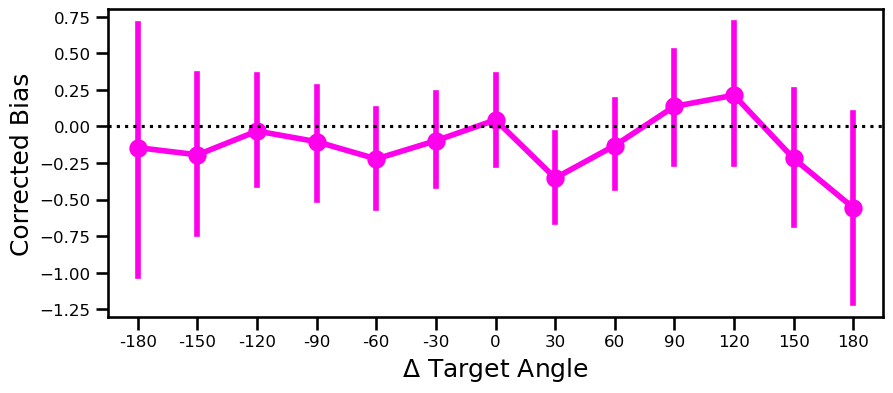

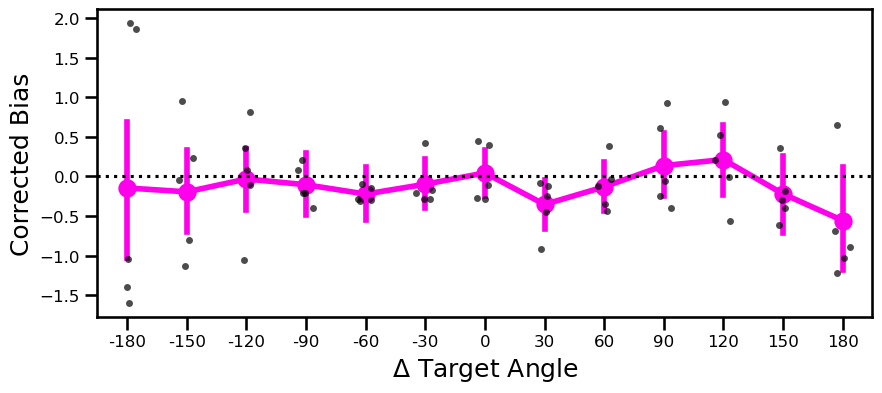

In [89]:
repulse_mask = (
    (df['TN'] >= epochs['repulse'][0]) & (df['TN'] <= epochs['repulse'][1]) & 
    (~df['mt'].isna()) & # take the median of the RT and MT and mean of the medians 
    (df['rt'] > 0.5) &  
    (np.abs(df['theta_pv']) < 60)
)

df_repulse = df.loc[repulse_mask]

subject_means_repulse = (
    df_repulse
    .groupby(['SN', 'target_angle_diff'])['corrected_repulse_theta_pv']
    .mean()
    .reset_index()
)


fig, ax = plt.subplots(figsize=(10,4))
sns.pointplot(
    data=df_repulse,
    # to look at a single subject (comment)
    # data = df_repulse.loc[df_repulse["SN"] == 2],
    x='target_angle_diff',
    y='corrected_repulse_theta_pv',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax
)
ax.axhline(0, color='black', linestyle=':')
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
plt.xlabel(r'$\Delta$ Target Angle')
plt.ylabel('Corrected Bias')

fig2, ax2 = plt.subplots(figsize=(10,4))
sns.pointplot(
    data=df_repulse,
    x='target_angle_diff',
    y='corrected_repulse_theta_pv',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax2
)
sns.stripplot(
    data=subject_means_repulse,
    x='target_angle_diff',
    y='corrected_repulse_theta_pv',
    color='black',
    alpha=0.7,
    jitter=0.15,
    size=5,
    ax=ax2
)
ax2.axhline(0, color='black', linestyle=':')
ax2.tick_params(axis='x', labelsize=12)
ax2.tick_params(axis='y', labelsize=12)
plt.xlabel(r'$\Delta$ Target Angle')
plt.ylabel('Corrected Bias')



# Plot biases in use-dependent phase

/var/folders/g6/bw3kklz96vl7dn2xz_xpz9440000gn/T/ipykernel_10351/291719705.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(N_finder, N_minus_targ=150)
/var/folders/g6/bw3kklz96vl7dn2xz_xpz9440000gn/T/ipykernel_10351/291719705.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=16, random_state=42))


Text(0, 0.5, 'Corrected Bias')

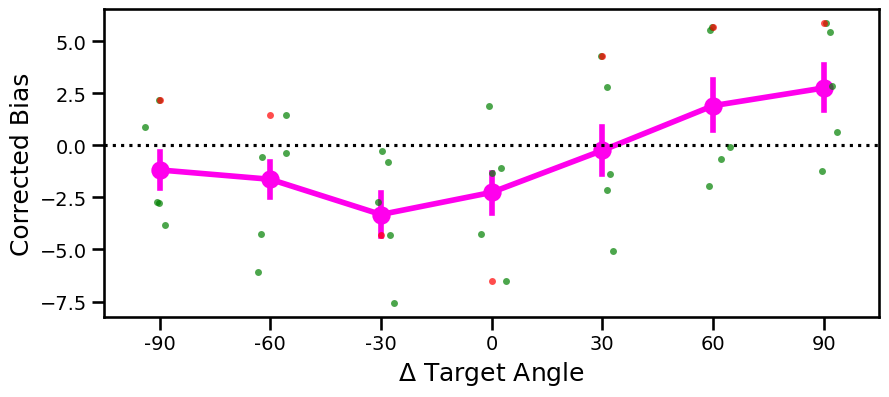

In [90]:
mask_udl = (
    (df['TN'] >= epochs['udl'][0]) & (df['TN'] <= epochs['udl'][1])
    & (~df['mt'].isna()) & (df['rt'] > 0.500) & (df['theta_pv'].abs() < 60))

df_udl = df.loc[mask_udl]

df_udl_constrained = (
    df_udl
    .groupby('SN', as_index=False)
    .apply(N_finder, N_minus_targ=150)
    .reset_index(drop=True)
)
df_udl_constrained = df_udl_constrained.loc[df_udl_constrained['feedback'] == 0]

# should i change so it stores the probe column??
# Split target_angle == 150 and everything else

df_target_150 = df_udl_constrained[df_udl_constrained['target_angle'] == 150]
df_other = df_udl_constrained[df_udl_constrained['target_angle'] != 150]
# Randomly keep 16 of the target_angle == 150 rows

df_target150_keep = (
    df_target_150
    .groupby('SN', group_keys=False)
    .apply(lambda x: x.sample(n=16, random_state=42))
    .reset_index(drop=True)
)

# Combine back together
df_udl_constrained = (
    pd.concat([df_other, df_target150_keep])
    .reset_index(drop=True)
)

subject_means = df_udl_constrained.groupby(['SN', 'target_angle_diff'])['corrected_repulse_theta_pv'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10,4))
sns.pointplot(
    data=df_udl_constrained,
    x='target_angle_diff',
    y='corrected_repulse_theta_pv',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax
)

sns.stripplot(
    data=subject_means,
    x='target_angle_diff',
    y='corrected_repulse_theta_pv',
    color='green',
    alpha=0.7,
    jitter=0.15,
    size=5,
    ax=ax
)

sns.stripplot(
    data=subject_means[subject_means['SN']==5],
    x='target_angle_diff',
    y='corrected_repulse_theta_pv',
    color='red',
    alpha=0.7,
    jitter=0.15,
    size=5,
    ax=ax
)

ax.axhline(0, color='black', linestyle=':')
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
plt.xlabel(r'$\Delta$ Target Angle')
plt.ylabel('Corrected Bias')

Text(0, 0.5, 'theta_pv')

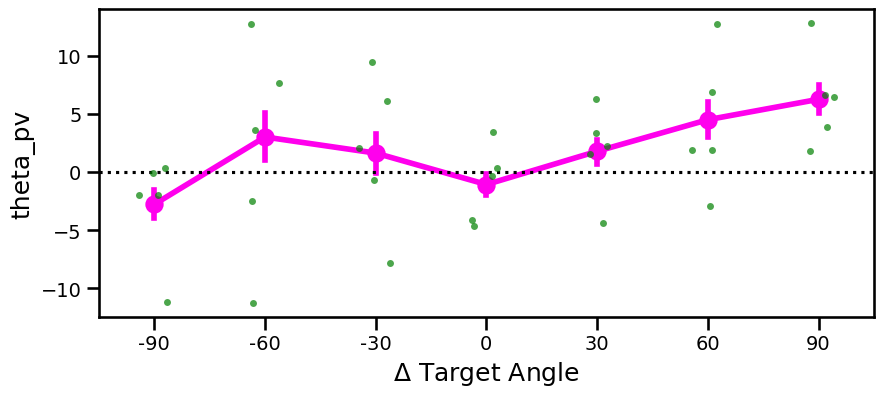

In [91]:
subject_means = df_udl_constrained.groupby(['SN', 'target_angle_diff'])['theta_pv'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10,4))
sns.pointplot(
    data=df_udl_constrained,
    x='target_angle_diff',
    y='theta_pv',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax
)

sns.stripplot(
    data=subject_means,
    x='target_angle_diff',
    y='theta_pv',
    color='green',
    alpha=0.7,
    jitter=0.15,
    size=5,
    ax=ax
)

ax.axhline(0, color='black', linestyle=':')
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
plt.xlabel(r'$\Delta$ Target Angle')
plt.ylabel('theta_pv')

## Checking validity of the bias calculation 

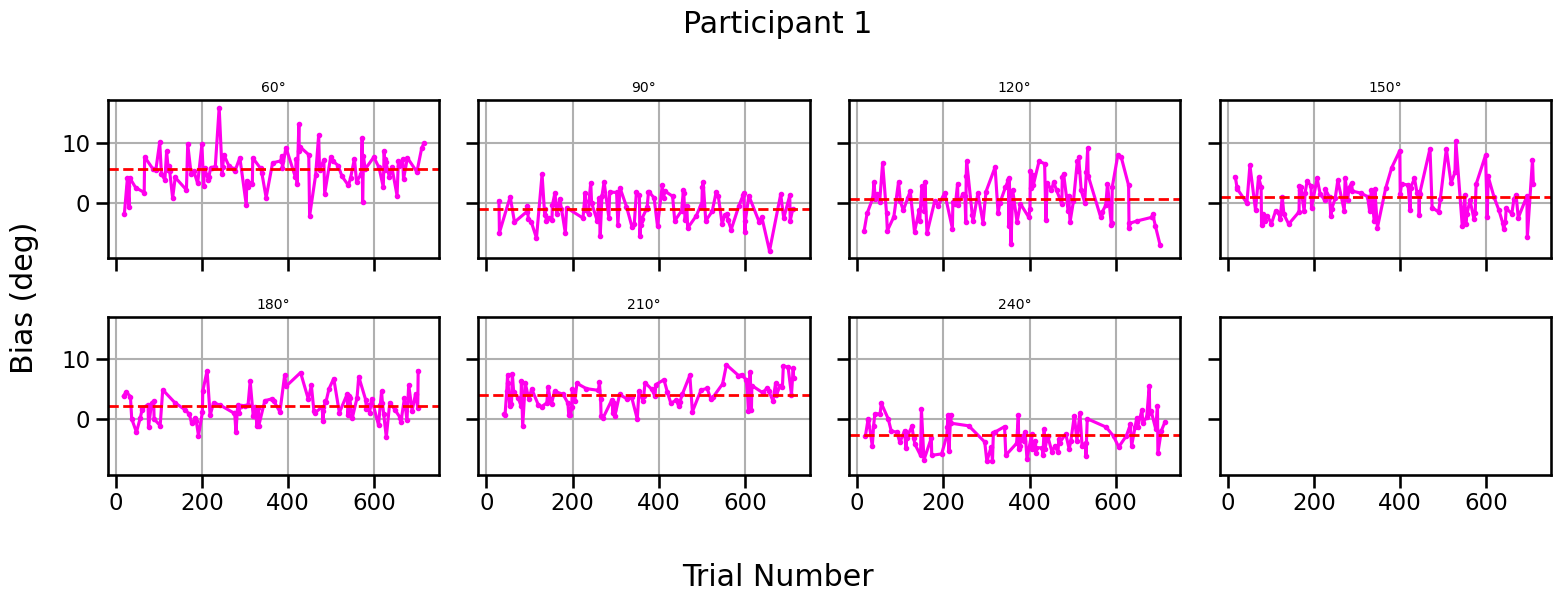

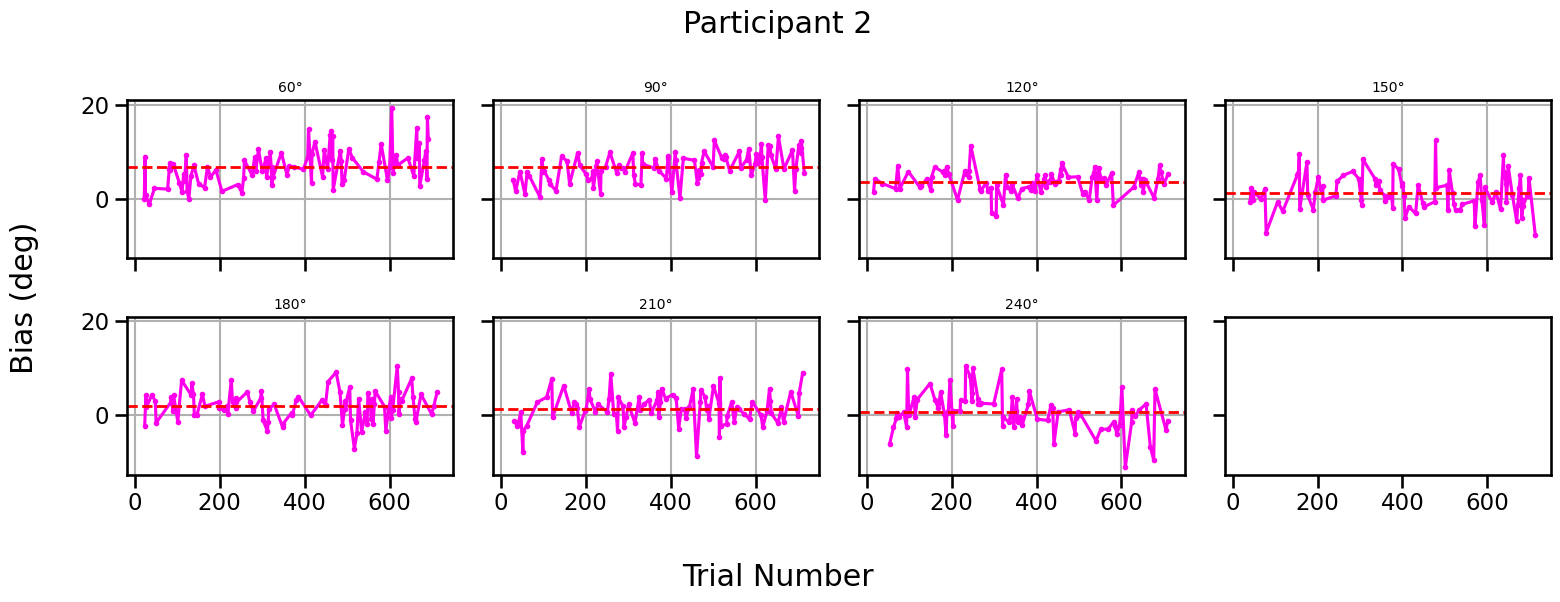

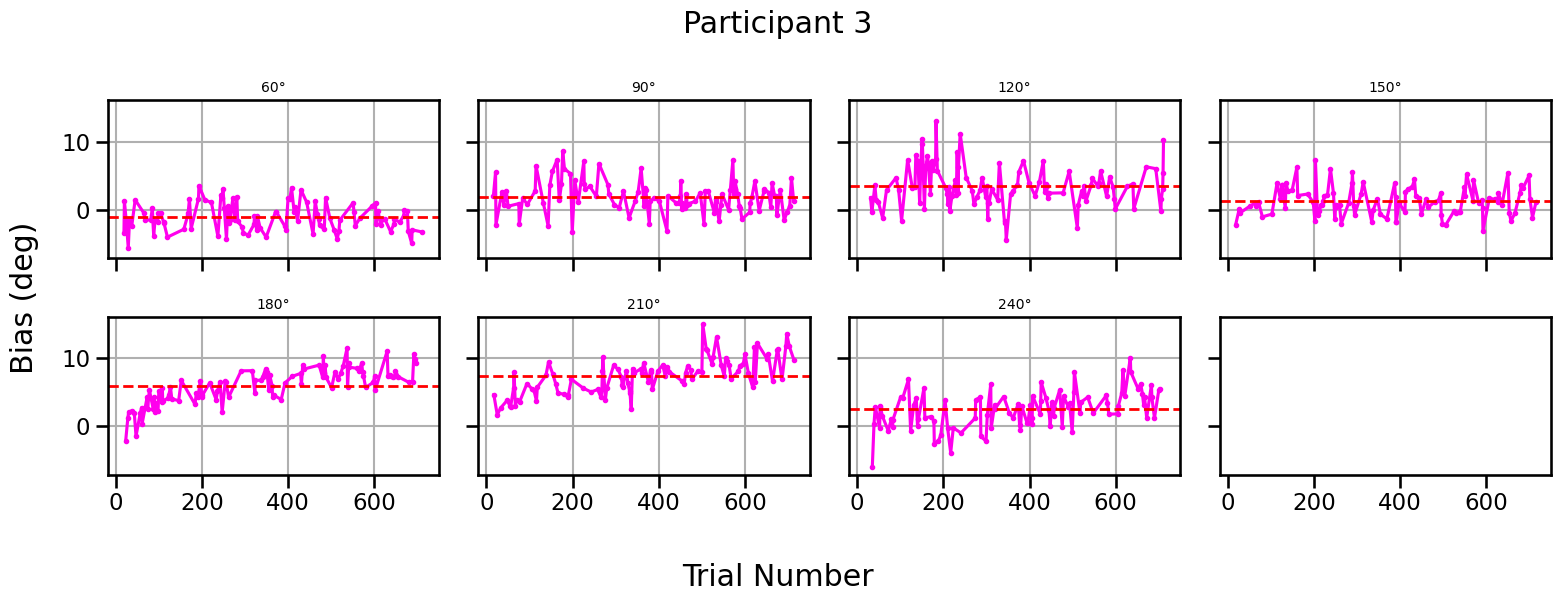

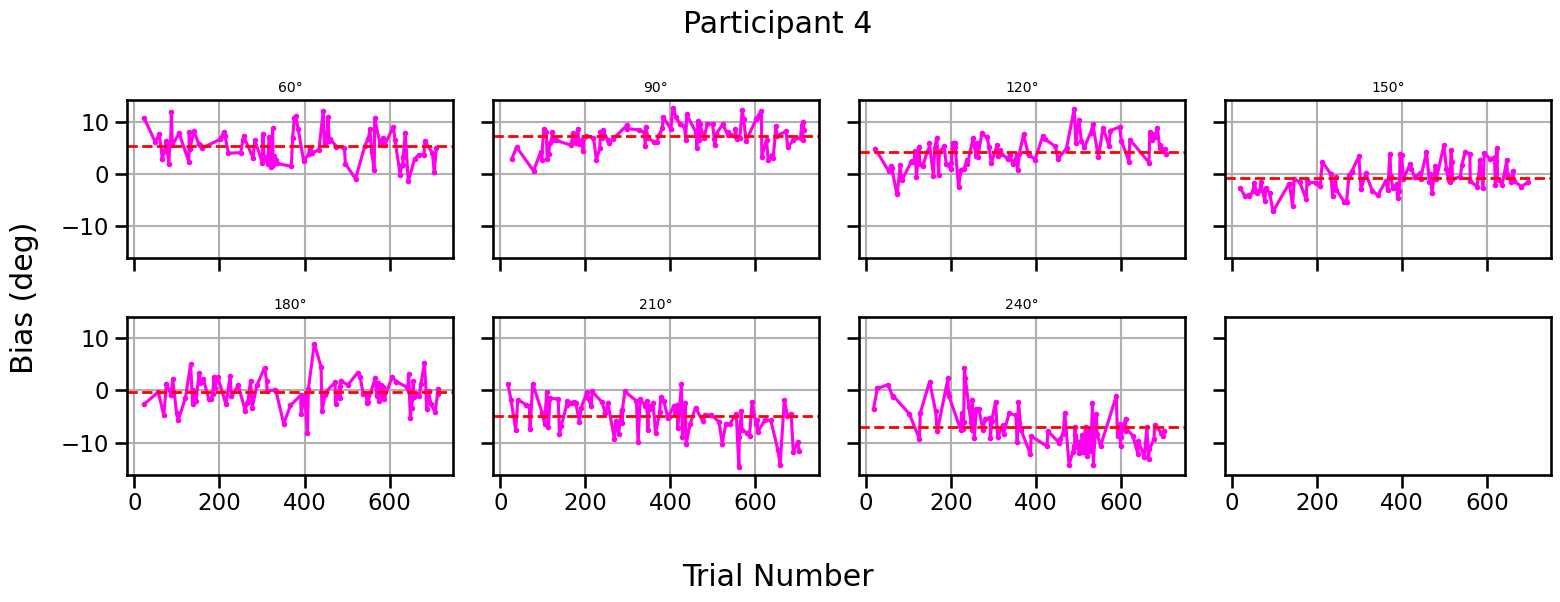

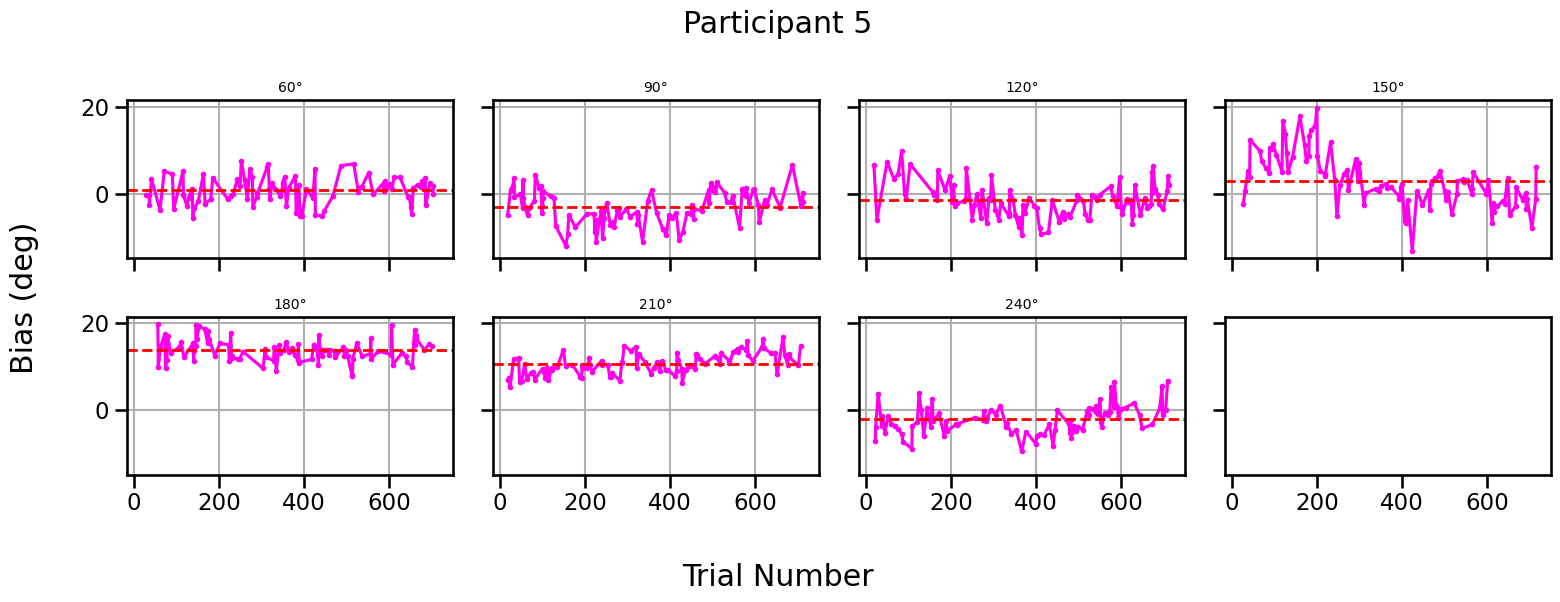

In [92]:
target_angles = sorted(df_repulse['target_angle'].unique())

for sn in df_repulse["SN"].unique():

    ncols = 4
    nrows = int(round(len(target_angles) / ncols,))

    fig, axes = plt.subplots(nrows, ncols,figsize=(4*ncols, 3*nrows),sharex=True,sharey=True)
    axes = np.array(axes).flatten()

    for ax, ta in zip(axes, target_angles):
        df_sn = (df_repulse[(df_repulse["SN"] == sn) &(df_repulse["target_angle"] == ta)].sort_values("TN"))

        ax.plot(df_sn["TN"],df_sn["theta_pv"],'o-',markersize=3)

        mean_val = df_sn["theta_pv"].mean()

        ax.axhline(y=mean_val,color='r',linestyle='--',linewidth=2)

        ax.set_title(f"{ta}°", fontsize=10)
        ax.grid(True)

    fig.suptitle(f"Participant {sn}")
    fig.supxlabel("Trial Number")
    fig.supylabel("Bias (deg)")

    plt.tight_layout()
    plt.show()

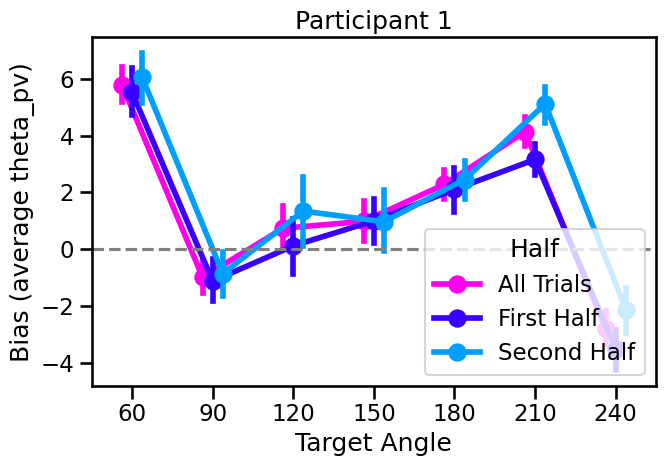

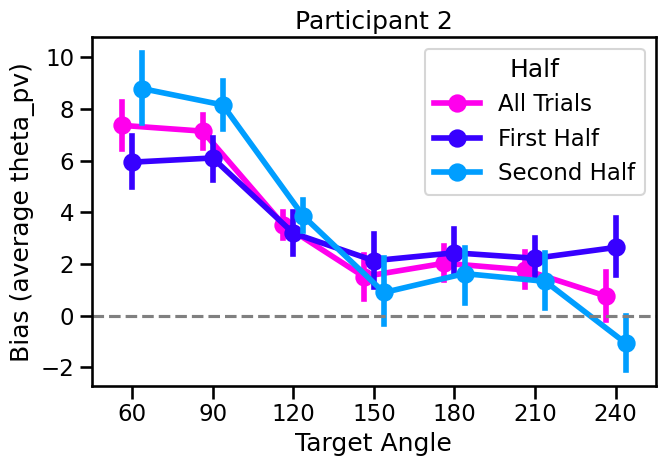

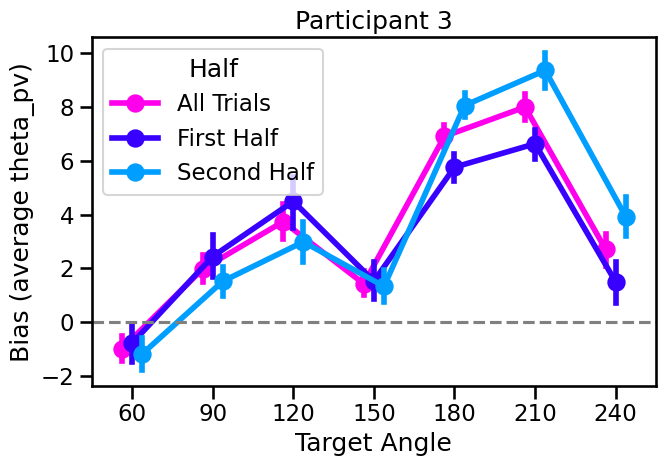

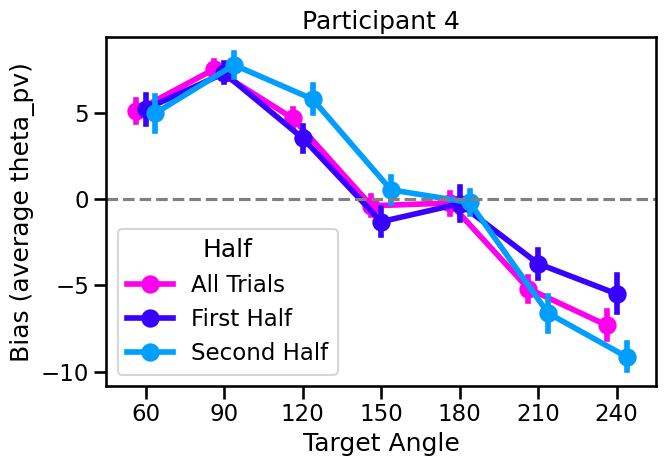

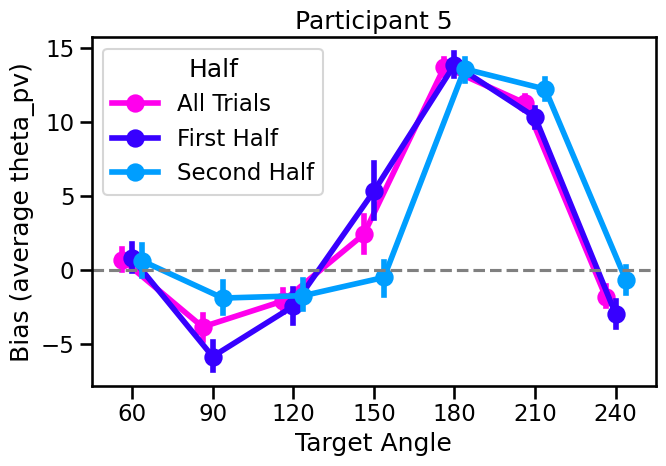

In [93]:
repulse_mask = (
    (df['TN'] >= epochs['repulse_clean'][0]) & (df['TN'] <= epochs['repulse_clean'][1]) & 
    (~df['mt'].isna()) &
    (df['rt'] > 0.5) &  
    (np.abs(df['theta_pv']) < 60)
)
df_repulse = df.loc[repulse_mask]

target_angles = sorted(df_repulse["target_angle"].unique())

for sn in df_repulse["SN"].unique():

    df_sn = df_repulse[df_repulse["SN"] == sn].copy()
    dfs = []

    for angle in target_angles:

        df_angle = df_sn[df_sn["target_angle"] == angle].copy()

        n = len(df_angle)
        half = n // 2

        first = df_angle.iloc[:half].copy()
        second = df_angle.iloc[half:].copy()

        df_angle["Half"] = "All Trials"
        first["Half"] = "First Half"
        second["Half"] = "Second Half"

        dfs.extend([df_angle, first, second])

    plot_df = pd.concat(dfs, ignore_index=True)

    plt.figure(figsize=(7,5))

    sns.pointplot(
        data=plot_df,
        x="target_angle",
        y="theta_pv",
        hue="Half",
        estimator="mean",
        errorbar=("ci", 95),
        dodge=0.25,
        linestyles="-"
    )

    plt.axhline(0, color='gray', linestyle='--')
    plt.xlabel("Target Angle")
    plt.ylabel("Bias (average theta_pv)")
    plt.title(f"Participant {sn}")
    plt.tight_layout()
    plt.show()

# Comparison of theta_40, theta_100, theta_pv, and theta_end 
## REPULSE 

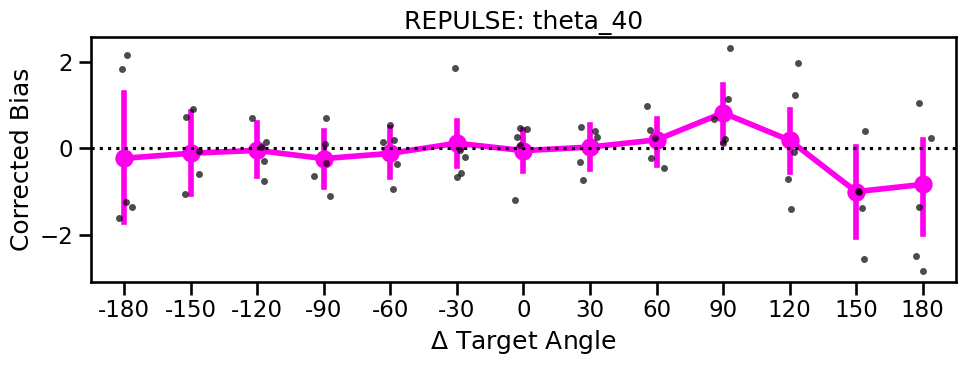

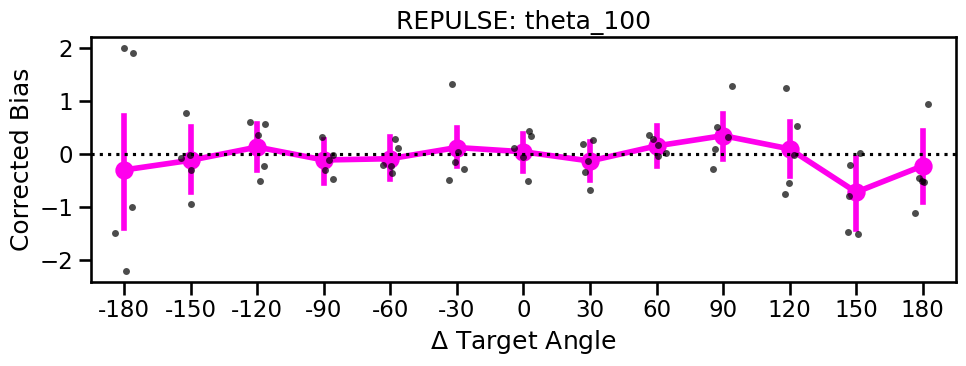

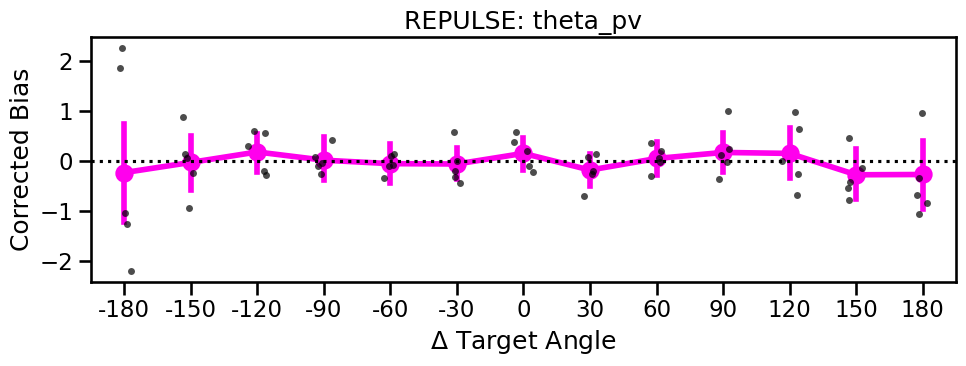

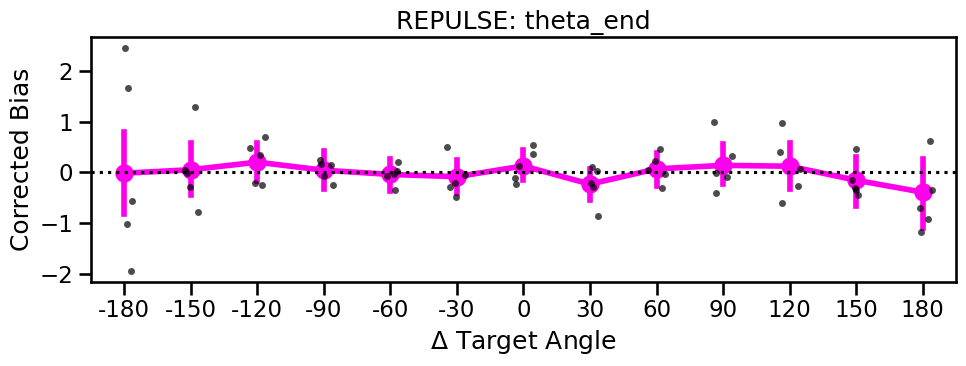

In [94]:
## plotting function
def plot_bias(df_plot, y_col, title):
    '''
    a plotting function that takes in a data frame, the y column (corrected angle), and the title for the graph 
    '''
    subject_means = (
        df_plot
        .groupby(["SN", "target_angle_diff"])[y_col]
        .mean()
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(10,4))

    sns.pointplot(
        data=df_plot,
        x="target_angle_diff",
        y=y_col,
        estimator="mean",
        errorbar=("ci",95),
        ax=ax
    )

    sns.stripplot(
        data=subject_means,
        x="target_angle_diff",
        y=y_col,
        color="black",
        alpha=0.7,
        jitter=0.15,
        size=5,
        ax=ax
    )

    ax.axhline(0, color="black", linestyle=":")
    ax.set_xlabel(r"$\Delta$ Target Angle")
    ax.set_ylabel("Corrected Bias")
    ax.set_title(title)

    plt.tight_layout()
    plt.show()

for angle in angle_cols:
    plot_bias(
        df_repulse,
        y_col=f"corrected_repulse_{angle}",
        title=f"REPULSE: {angle}"
    )

## UDL

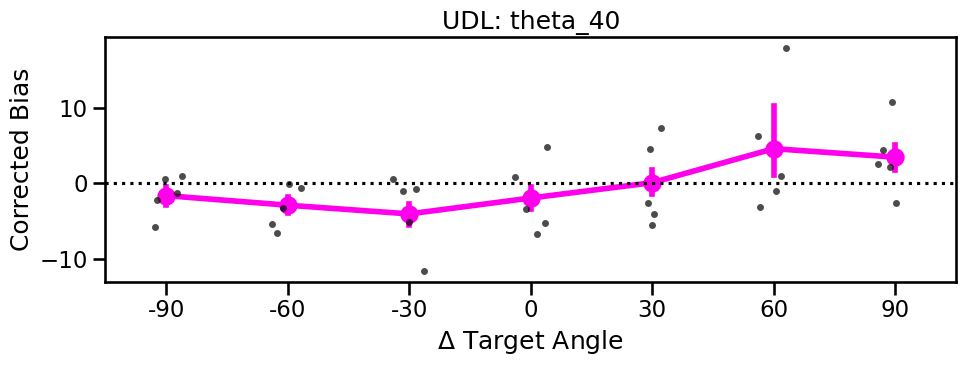

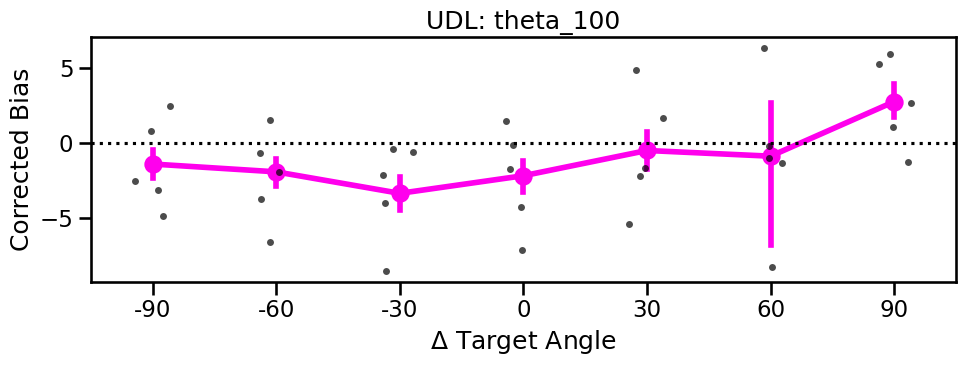

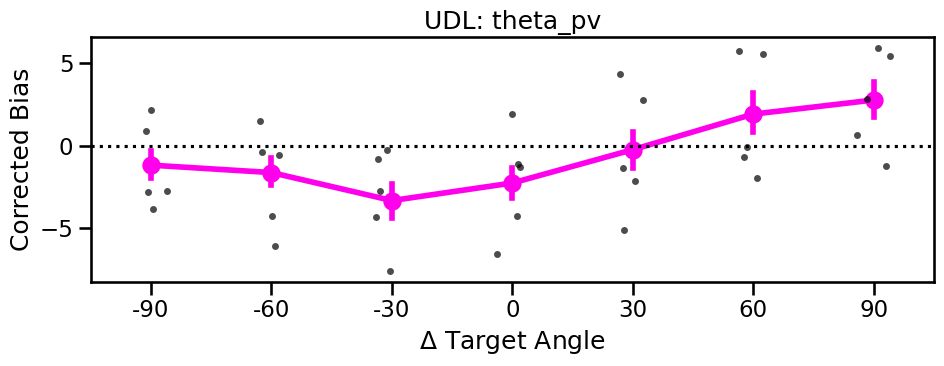

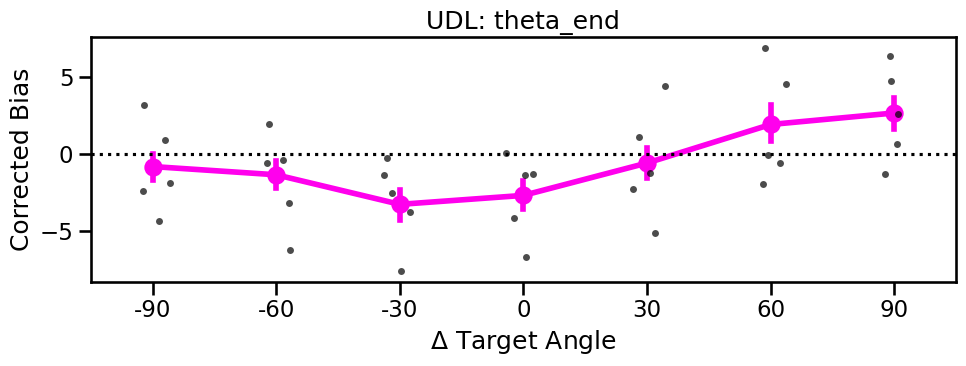

In [95]:
for angle in angle_cols:
    plot_bias(
        df_udl_constrained,
        y_col=f"corrected_repulse_{angle}",
        title=f"UDL: {angle}"
    )
 

 #bias_repulse_theta_100
#corrected_repulse

## Working with different movement times 

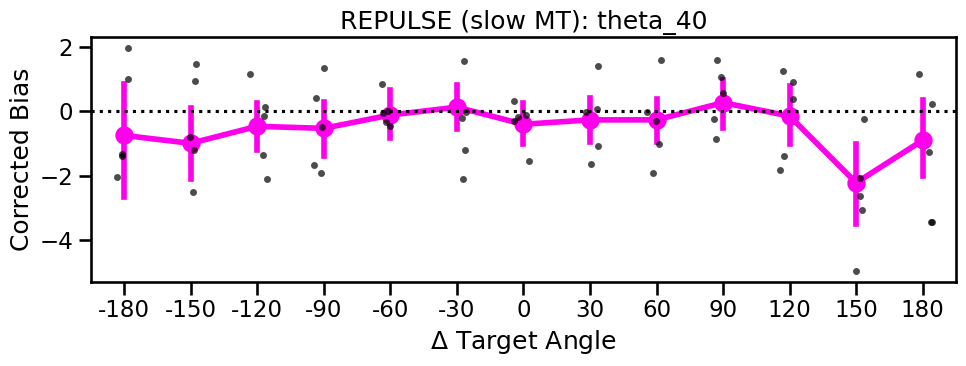

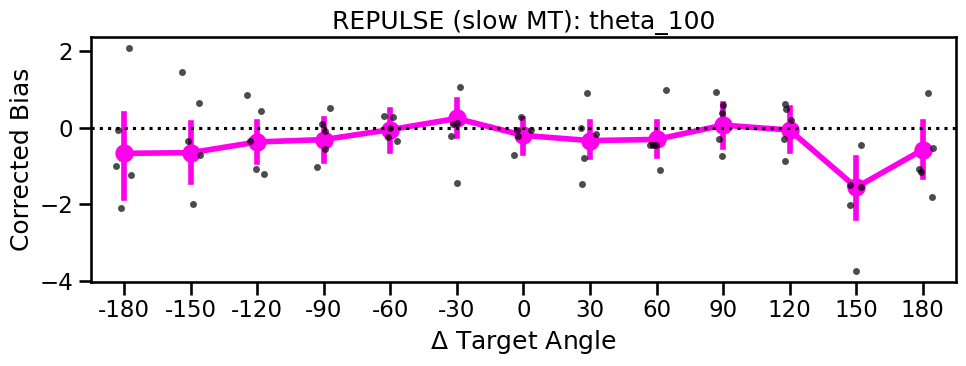

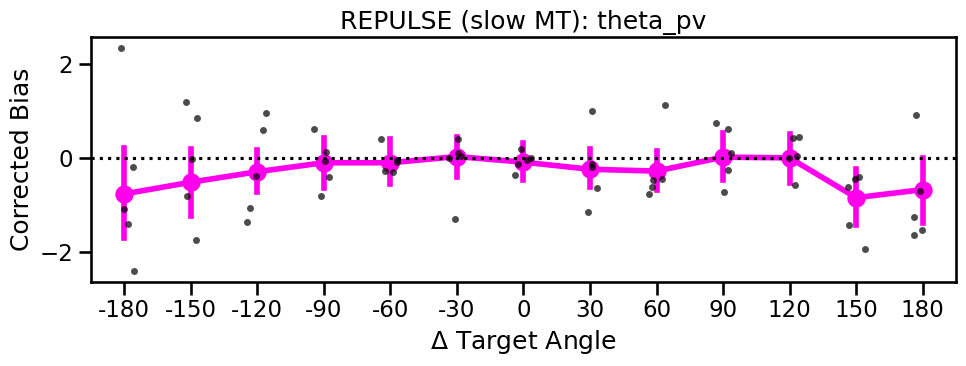

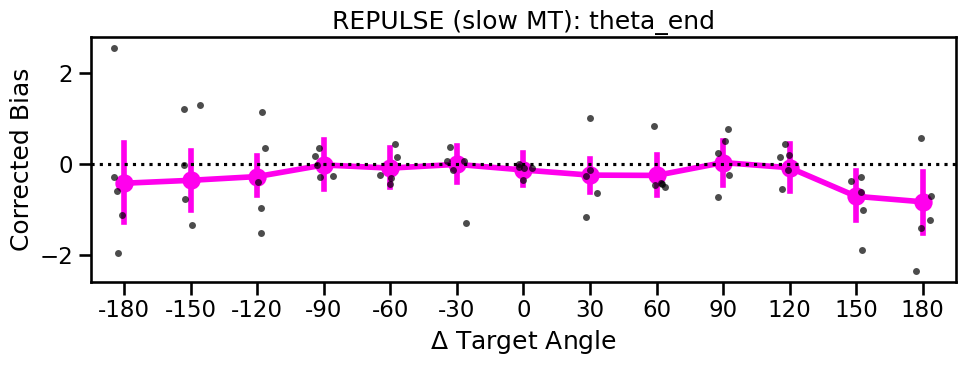

In [96]:
repulse_mask = (
    (df['TN'] >= epochs['repulse'][0]) & (df['TN'] <= epochs['repulse'][1]) & 
    (~df['mt'].isna()) &
    (df['mt'] > df['mt'].median()) & ## change this so that MT must be smaller than a certain  value. 
    (df['rt']  >0.5) &  
    (np.abs(df['theta_pv']) < 60)
)

df_repulse_slow = df.loc[repulse_mask]

for angle in angle_cols:
    plot_bias(
        df_repulse_slow,
        y_col=f"corrected_repulse_{angle}",
        title=f"REPULSE (slow MT): {angle}"
    )

/var/folders/g6/bw3kklz96vl7dn2xz_xpz9440000gn/T/ipykernel_10351/4134885814.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(N_finder, N_minus_targ=150)


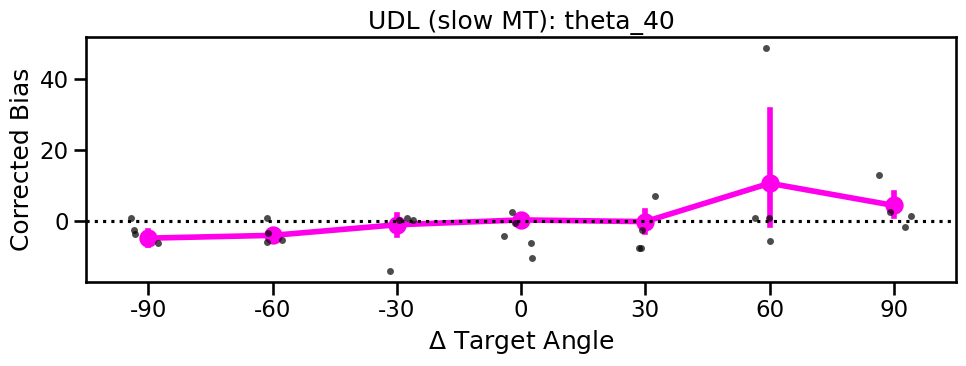

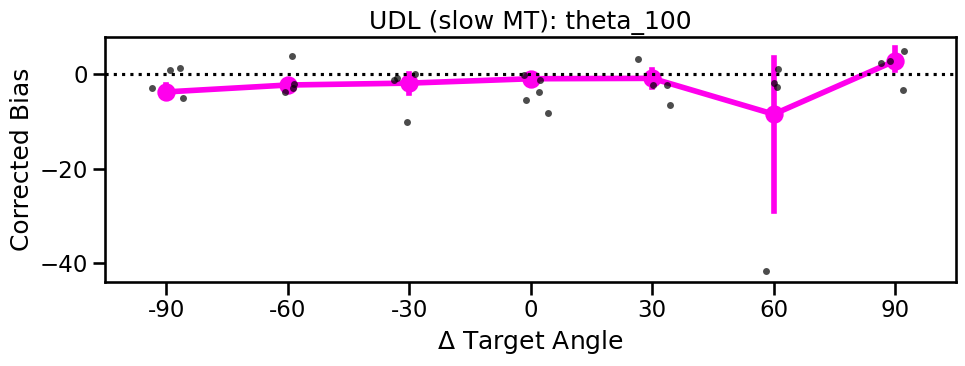

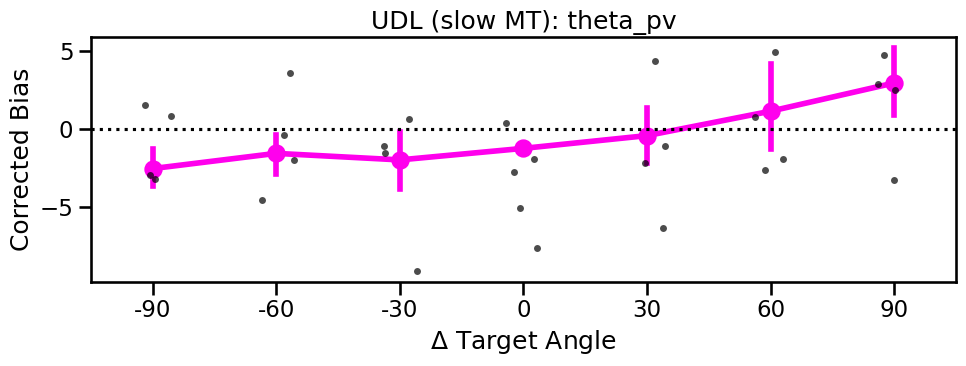

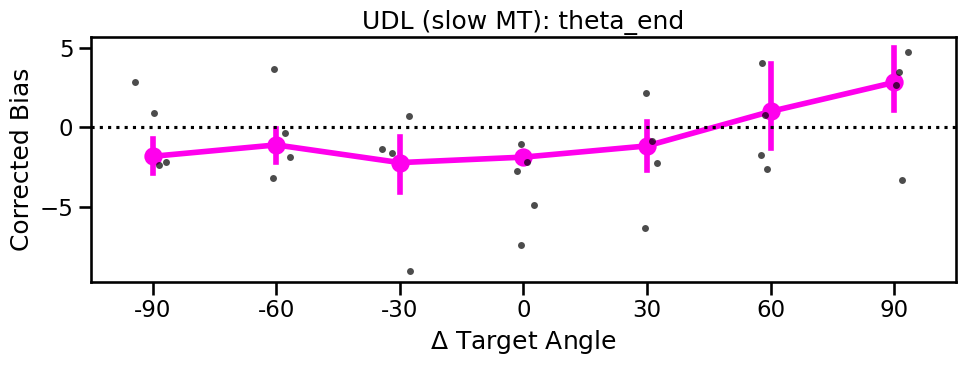

In [97]:
mask_udl = (
    (df['TN'] >= epochs['udl'][0]) & (df['TN'] <= epochs['udl'][1]) & 
    (~df['mt'].isna()) & 
    (df['mt'] > df['mt'].median()) & ## constrain the MT 
    (df['rt'] > 0.500) & 
    (df['theta_pv'].abs() < 60)
)

df_udl = df.loc[mask_udl]

df_udl_constrained_slow = (
    df_udl
    .groupby('SN', as_index=False)
    .apply(N_finder, N_minus_targ=150)
    .reset_index(drop=True)
)

df_udl_constrained_slow = df_udl_constrained_slow.loc[df_udl_constrained_slow['feedback'] == 0]

for angle in angle_cols:
    plot_bias(
        df_udl_constrained_slow,
        y_col=f"corrected_repulse_{angle}",
        title=f"UDL (slow MT): {angle}"
    )

## Movement Speed 

(Wong & Haith, 2017)

‘Fast’ (peak velocity, **0.8–1.5 m/s**)

‘Slow’ (peak velocity, **0.3–0.7 m/s**)

look at the peak velocity per participant, both WITH FB and WITHOUT FB 

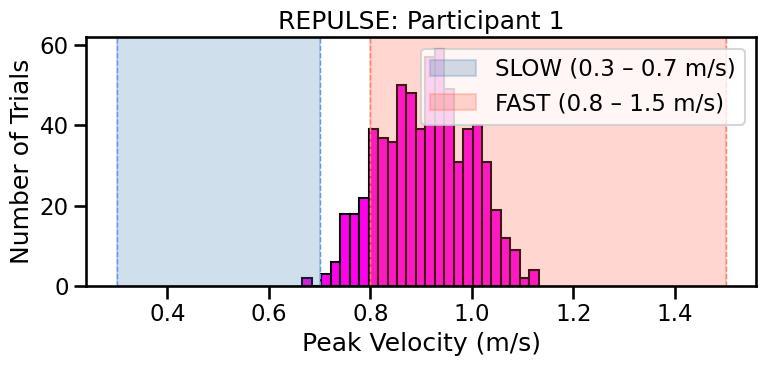

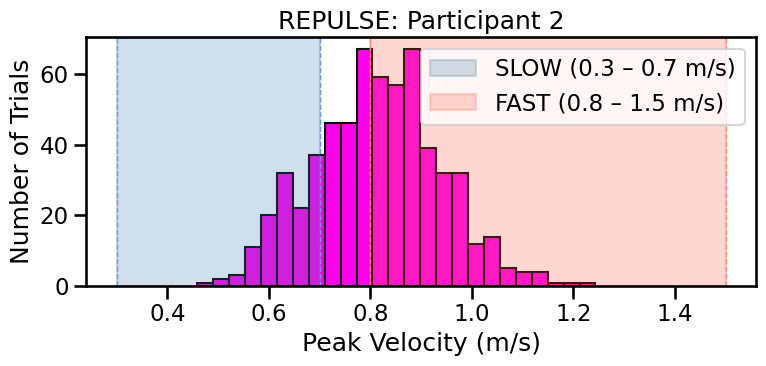

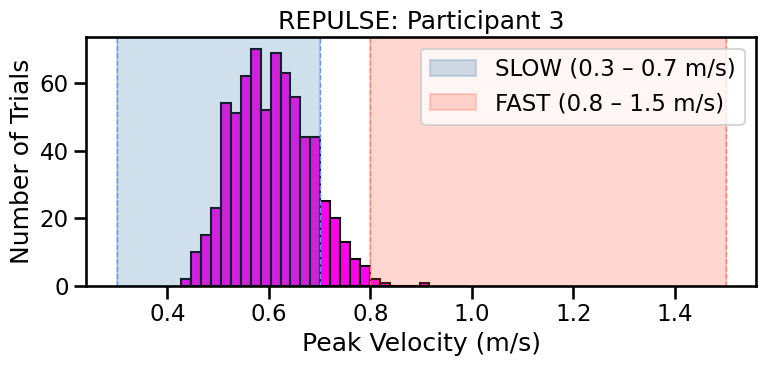

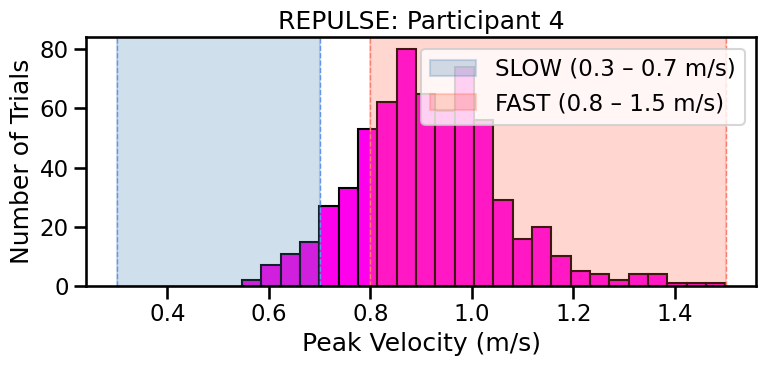

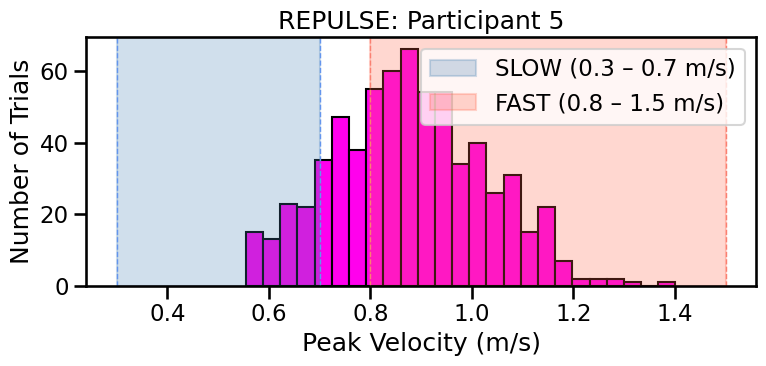

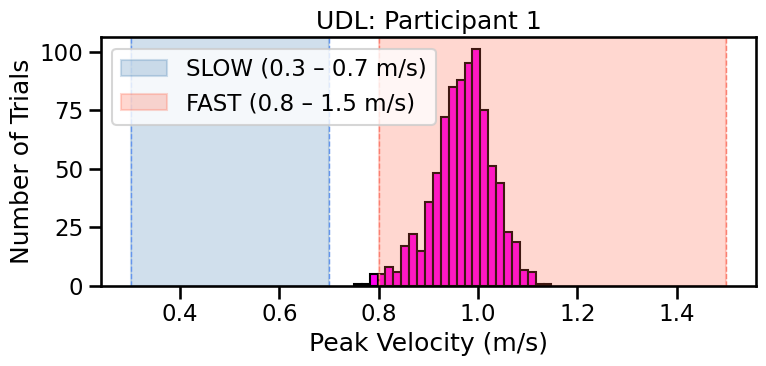

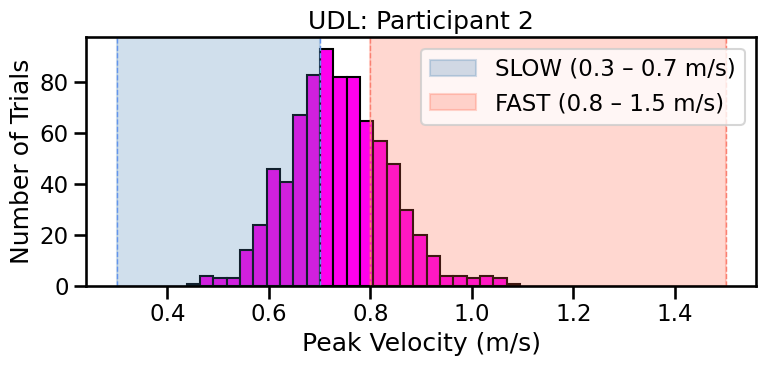

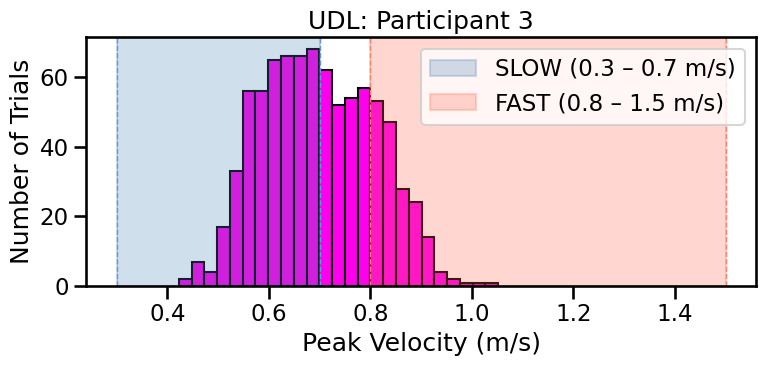

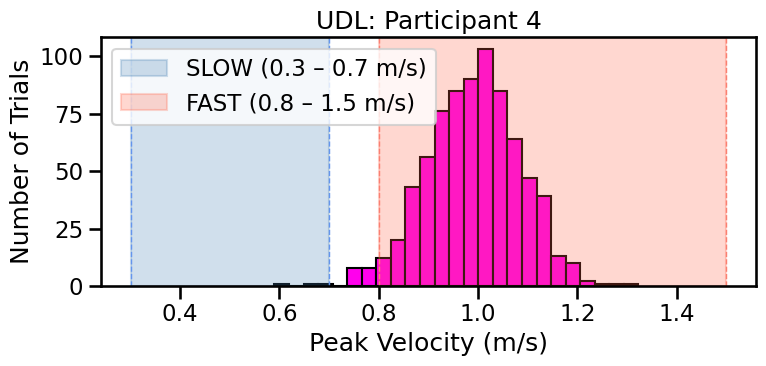

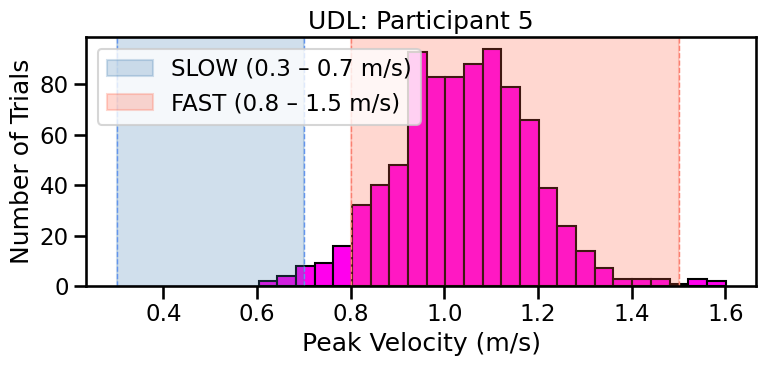

In [98]:
mask_repulse = (
    (df["TN"] >= epochs["repulse"][0]) &
    (df["TN"] <= epochs["repulse"][1]) &
    (~df["mt"].isna()) &
    (df["rt"] > 0.500) &
    (df["theta_pv"].abs() < 60)
)

mask_udl = (
    (df["TN"] >= epochs["udl"][0]) &
    (df["TN"] <= epochs["udl"][1]) &
    (~df["mt"].isna()) &
    (df["rt"] > 0.500) &
    (df["theta_pv"].abs() < 60)
)

df_repulse = df.loc[mask_repulse]
df_udl = df.loc[mask_udl]


def plot_peak_velocity_histograms(df, phase_name, bins):
    """
    plotting function for peak velocity histograms for each participant; 
    regions for 'FAST' and 'SLOW' are indicated in red and blue respectively
    """

    subjects = sorted(df["SN"].unique())

    for sn in subjects:

        pv = df.loc[df["SN"] == sn, "peak_vel"].dropna()

        fig, ax = plt.subplots(figsize=(8, 4))

        # plot histogram
        ax.hist(
            pv,
            bins=bins,
            edgecolor="black")

        # SLOW shaded region
        ax.axvspan(
            0.3,
            0.7,
            alpha=0.25,
            color="steelblue",
            label="SLOW (0.3 – 0.7 m/s)")

        # FAST shaded region
        ax.axvspan(
            0.8,
            1.5,
            alpha=0.25,
            color="tomato",
            label="FAST (0.8 – 1.5 m/s)")

        # Region boundaries
        ax.axvline(0.3, color="cornflowerblue", linestyle="--", linewidth=1)
        ax.axvline(0.7, color="cornflowerblue", linestyle="--", linewidth=1)

        ax.axvline(0.8, color="salmon", linestyle="--", linewidth=1)
        ax.axvline(1.5, color="salmon", linestyle="--", linewidth=1)

        ax.set_title(f"{phase_name}: Participant {sn}")
        ax.set_xlabel("Peak Velocity (m/s)")
        ax.set_ylabel("Number of Trials")

        ax.legend()
        plt.tight_layout()
        plt.show()


plot_peak_velocity_histograms(df_repulse, "REPULSE", 25)
plot_peak_velocity_histograms(df_udl, "UDL", 25)